# Red Neuronal de Grafos + LSTM — Sistema Financiero Ecuador
Predecir la morosidad total de cada entidad financiera (bancos y cooperativas) usando una red heterogénea de grafos combinada con LSTM.

**Arquitectura:**
- Nodos tipo `banco` y tipo `cooperativa` con features propias
- Aristas construidas dinámicamente por período sobre similitud coseno
- Capas HGTConv (Heterogeneous Graph Transformer) → LSTM → predicción de morosidad



## Instalación
Instala PyTorch Geometric compatible con el entorno de Colab Pro con GPU.

In [16]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

# PyG no necesita torch-scatter ni torch-sparse por separado???
!pip install -q torch-geometric
!pip install -q scikit-learn pandas openpyxl matplotlib seaborn networkx tqdm

print('-- Instalación completa')

PyTorch version : 2.10.0+cu128
CUDA disponible : True
GPU             : Tesla T4
-- Instalación completa


## Montar Google Drive y cargar datos

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
import numpy as np

DRIVE_PATH = '/content/drive/MyDrive/GNN_SF/'

SB   = pd.read_excel(DRIVE_PATH + 'data/balance_indicadores_SB_limpio.xlsx', index_col=[0])
SEPS = pd.read_excel(DRIVE_PATH + 'data/balance_indicadores_SEPS_limpio.xlsx', index_col=[0])

print(f'SB   shape : {SB.shape}')
print(f'SEPS shape : {SEPS.shape}')
print()
print('─── Primeras columnas SB ───')
print(SB.columns[:10].tolist())
print()
print('─── Primeras columnas SEPS ───')
print(SEPS.columns[:10].tolist())

SB   shape : (5399, 137)
SEPS shape : (4178, 127)

─── Primeras columnas SB ───
['razonSocial', 'fechaCorte', '1', '11', '1101', '1103', '110305', '110310', '1303', '14']

─── Primeras columnas SEPS ───
['razonSocial', 'fechaCorte', '1', '11', '1101', '1103', '110305', '110310', '1303', '14']


## Exploración y limpieza básica

In [20]:
# Verificar columnas clave
for nombre, df in [('SB', SB), ('SEPS', SEPS)]:
    print(f'=== {nombre} ===')
    print(f"  Columna 'razonSocial' presente : {'razonSocial' in df.columns}")
    print(f"  Columna 'fechaCorte'  presente : {'fechaCorte'  in df.columns}")
    print(f"  Columna 'morosidad_total' presente : {'morosidad_total' in df.columns}")
    print(f"  Períodos únicos       : {df['fechaCorte'].nunique()}")
    print(f"  Entidades únicas      : {df['razonSocial'].nunique()}")
    print(f"  Rango fechas          : {df['fechaCorte'].min()} → {df['fechaCorte'].max()}")
    print()

=== SB ===
  Columna 'razonSocial' presente : True
  Columna 'fechaCorte'  presente : True
  Columna 'morosidad_total' presente : True
  Períodos únicos       : 273
  Entidades únicas      : 22
  Rango fechas          : 2003-01-31 00:00:00 → 2025-09-30 00:00:00

=== SEPS ===
  Columna 'razonSocial' presente : True
  Columna 'fechaCorte'  presente : True
  Columna 'morosidad_total' presente : True
  Períodos únicos       : 117
  Entidades únicas      : 71
  Rango fechas          : 2016-01-31 00:00:00 → 2025-09-30 00:00:00



In [21]:
# Asegurar tipo datetime en fechaCorte
SB['fechaCorte']   = pd.to_datetime(SB['fechaCorte'])
SEPS['fechaCorte'] = pd.to_datetime(SEPS['fechaCorte'])

# Etiquetar tipo de entidad
SB['tipo']   = 'banco'
SEPS['tipo'] = 'cooperativa'

# Revisar valores nulos en morosidad_total
print('Nulos en morosidad_total:')
print(f'  SB   : {SB["morosidad_total"].isna().sum()}')
print(f'  SEPS : {SEPS["morosidad_total"].isna().sum()}')

Nulos en morosidad_total:
  SB   : 0
  SEPS : 0


## Definición de features por tipo de nodo

In [22]:
# ─── Features COMUNES (disponibles en SB y SEPS) ──────────────────────────────
FEATURES_COMUNES = [
    'comercial_priorit_ndi_vs_cartera',
    'consumo_priorit_ndi_vs_cartera',
    'inmobiliario_ndi_vs_cartera',
    'micro_ndi_vs_cartera',
    'comercial_priorit_vencida_vs_cartera',
    'consumo_priorit_vencida_vs_cartera',
    'inmobiliario_vencido_vs_cartera',
    'micro_vencido_vs_cartera',
    'provisiones_cred_incobr_vs_cartera',
    'refinanciada_vs_cartera',
    'reestructurada_vs_cartera',
    'cxc_inversion_vs_cxc',
    'cxc_cartera_creditos_vs_cxc',
    'depreciacion_acum_vs_propiedad',
    'otros_activos_vs_activo',
    'inv_acciones_y_particip_vs_activo',
    'en_otras_inst_finan_vs_activo',
    'depositos_a_la_vista_vs_pasivo',
    'depositos_a_plazo_vs_pasivo',
    'oblig_con_ifis_y_sector_f_vs_pasivo',
    'oblig_ifis_sector_publico_vs_pasivo',
    'otros_pasivos_vs_pasivos',
    'capital_social_vs_patrimonio',
    'reservas_vs_patrimonio',
    'resultados_vs_patrimonio',
    'gastos_vs_patrimonio',
    'provisiones_vs_patrimonio',
    'gastos_operacion_vs_patrimonio',
    'fondos_disponibles_vs_activos',
    'caja_vs_fondos_disp',
    'bancos_y_otras_inst_finan_vs_fondos_disp',
    'banco_central_vs_bancos_y_otr',
    'bancos_locales_vs_bancos_y_otr',
    'comercial_prioritario_xvencer_vs_cartera',
    'consumo_prioritario_xvencer_vs_cartera',
    'inmobiliario_xvencer_vs_cartera',
    'micro_xvencer_vs_cartera',
    'depositos_vs_ingresos',
    'intereses_descuentos_inv_vs_ingresos',
    'intereses_cartera_creditos_vs_ingresos',
    'comisiones_vs_ingresos',
    'ingresos_servicios_vs_ingresos',
    'otros_ingresos_vs_ingresos',
    'cuentas_contingentes_vs_activo',
]

# ─── Features EXCLUSIVAS de SB (bancos) ───────────────────────────────────────
# Hay que excluir las variables originales que tienen nombres de códigos de cuentas
import re

def es_columna_numerica_original(col):
    return bool(re.fullmatch(r'\d+', col))

cols_excluir = set(['razonSocial', 'fechaCorte', 'tipo', 'morosidad_total'] + FEATURES_COMUNES)

FEATURES_SB = [
    c for c in SB.columns
    if c not in cols_excluir
    and not es_columna_numerica_original(c)
]

FEATURES_SEPS = [
    c for c in SEPS.columns
    if c not in cols_excluir
    and not es_columna_numerica_original(c)
]

# Features de nodo completas por tipo
FEATURES_NODO_BANCO = FEATURES_COMUNES + FEATURES_SB
FEATURES_NODO_COOP  = FEATURES_COMUNES + FEATURES_SEPS

TARGET = 'morosidad_total'

print(f'Features comunes        : {len(FEATURES_COMUNES)}')
print(f'Features exclusivas SB  : {len(FEATURES_SB)}')
print(f'Features exclusivas SEPS: {len(FEATURES_SEPS)}')
print(f'Dim nodo banco          : {len(FEATURES_NODO_BANCO)}')
print(f'Dim nodo cooperativa    : {len(FEATURES_NODO_COOP)}')

Features comunes        : 44
Features exclusivas SB  : 38
Features exclusivas SEPS: 28
Dim nodo banco          : 82
Dim nodo cooperativa    : 72


In [23]:
# Verificar que todos los features existen en los dataframes
faltantes_SB   = [f for f in FEATURES_NODO_BANCO if f not in SB.columns]
faltantes_SEPS = [f for f in FEATURES_NODO_COOP  if f not in SEPS.columns]

if faltantes_SB:
    print(f' Features faltantes en SB   : {faltantes_SB}')
else:
    print('Todos los features de banco están en SB')

if faltantes_SEPS:
    print(f'Features faltantes en SEPS : {faltantes_SEPS}')
else:
    print('Todos los features de cooperativa están en SEPS')

Todos los features de banco están en SB
Todos los features de cooperativa están en SEPS


## Universo global de entidades y normalización

In [24]:
from sklearn.preprocessing import RobustScaler

# ─── Universo global ──────────────────────────────────────────────────────────
# Todas las entidades que existieron alguna vez (pueden entrar/salir)
bancos_universo = sorted(SB['razonSocial'].unique())
coops_universo  = sorted(SEPS['razonSocial'].unique())

banco2idx = {b: i for i, b in enumerate(bancos_universo)}
coop2idx  = {c: i for i, c in enumerate(coops_universo)}

N_BANCOS = len(bancos_universo)
N_COOPS  = len(coops_universo)

print(f'Bancos en el universo      : {N_BANCOS}')
print(f'Cooperativas en el universo: {N_COOPS}')
print(f'Total nodos                : {N_BANCOS + N_COOPS}')

Bancos en el universo      : 22
Cooperativas en el universo: 71
Total nodos                : 93


In [25]:
# ─── Normalización con RobustScaler (robusto a outliers financieros) ──────────
# Se ajusta sobre TODOS los datos de entrenamiento (se define el split primero)

# Períodos disponibles en orden cronológico
periodos = sorted(set(SB['fechaCorte'].unique()) | set(SEPS['fechaCorte'].unique()))
print(f'Períodos totales: {len(periodos)}')
print(f'Primer período  : {periodos[0]}')
print(f'Último período  : {periodos[-1]}')

# Split temporal: 80% train, 10% val, 10% test
n = len(periodos)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

periodos_train = periodos[:n_train]
periodos_val   = periodos[n_train:n_train + n_val]
periodos_test  = periodos[n_train + n_val:]

print(f'\nSplit temporal:')
print(f'  Train : {len(periodos_train)} períodos ({periodos_train[0]} → {periodos_train[-1]})')
print(f'  Val   : {len(periodos_val)}  períodos ({periodos_val[0]}  → {periodos_val[-1]})')
print(f'  Test  : {len(periodos_test)}  períodos ({periodos_test[0]}  → {periodos_test[-1]})')

Períodos totales: 273
Primer período  : 2003-01-31 00:00:00
Último período  : 2025-09-30 00:00:00

Split temporal:
  Train : 218 períodos (2003-01-31 00:00:00 → 2021-02-28 00:00:00)
  Val   : 27  períodos (2021-03-31 00:00:00  → 2023-05-31 00:00:00)
  Test  : 28  períodos (2023-06-30 00:00:00  → 2025-09-30 00:00:00)


In [26]:
# Ajustar escaladores solo con datos de train
SB_train   = SB[SB['fechaCorte'].isin(periodos_train)]
SEPS_train = SEPS[SEPS['fechaCorte'].isin(periodos_train)]

scaler_banco = RobustScaler()
scaler_coop  = RobustScaler()
scaler_target_banco = RobustScaler()
scaler_target_coop  = RobustScaler()

# Rellenar NaN con mediana antes de escalar
def preparar_features(df, features):
    X = df[features].copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    col_medians = X.median()
    col_medians = col_medians.fillna(0)
    X = X.fillna(col_medians)
    X = X.fillna(0)
    return X

scaler_banco.fit(preparar_features(SB_train, FEATURES_NODO_BANCO))
scaler_coop.fit(preparar_features(SEPS_train, FEATURES_NODO_COOP))
scaler_target_banco.fit(SB_train[['morosidad_total']].fillna(0))
scaler_target_coop.fit(SEPS_train[['morosidad_total']].fillna(0))

print('Escaladores ajustados sobre datos de entrenamiento')

Escaladores ajustados sobre datos de entrenamiento


## Construcción de snapshots y aristas dinámicas

In [27]:
import torch
from torch_geometric.data import HeteroData
from sklearn.metrics.pairwise import cosine_similarity

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def construir_aristas_knn(X: np.ndarray, k: int = 5):
    """
    Construye aristas k-NN basadas en similitud coseno entre filas de X.
    Retorna edge_index (2, E) y edge_attr (E, 1) con la similitud.
    Garantiza que ningún nodo quede aislado independiente del umbral.
    """
    n = len(X)
    if n <= 1:
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0, 1))

    k = min(k, n - 1)  # no puede haber más vecinos que nodos - 1
    sim = cosine_similarity(X)           # (n, n)
    np.fill_diagonal(sim, -2)            # excluir auto-conexiones

    top_k_idx = np.argsort(sim, axis=1)[:, -k:]  # k vecinos más similares
    filas = np.repeat(np.arange(n), k)
    cols  = top_k_idx.flatten()

    similitud_vals = sim[filas, cols].reshape(-1, 1)

    # Aristas bidireccionales
    edge_index = np.stack([np.concatenate([filas, cols]),
                           np.concatenate([cols, filas])], axis=0)
    edge_attr  = np.vstack([similitud_vals, similitud_vals])

    # Deduplicar
    edges_set = set(map(tuple, edge_index.T.tolist()))
    edge_index = np.array(list(edges_set)).T
    # Recalcular edge_attr para las aristas deduplicadas
    edge_attr = sim[edge_index[0], edge_index[1]].reshape(-1, 1)

    return edge_index.astype(np.int64), edge_attr.astype(np.float32)


def build_snapshot(fecha, SB_df, SEPS_df, K_INTRA=5, K_INTER=3):
    """
    Construye un HeteroData para un período dado.
    Maneja entidades activas/inactivas automáticamente con máscara.
    """
    snapshot = HeteroData()

    # ── Datos del período ──────────────────────────────────────────────────────
    sb_t   = SB_df[SB_df['fechaCorte'] == fecha].set_index('razonSocial')
    seps_t = SEPS_df[SEPS_df['fechaCorte'] == fecha].set_index('razonSocial')

    bancos_activos = [b for b in bancos_universo if b in sb_t.index]
    coops_activas  = [c for c in coops_universo  if c in seps_t.index]

    # ── Features de nodo bancos ────────────────────────────────────────────────
    X_banco_full = np.zeros((N_BANCOS, len(FEATURES_NODO_BANCO)), dtype=np.float32)
    mask_banco   = np.zeros(N_BANCOS, dtype=bool)
    y_banco      = np.zeros(N_BANCOS, dtype=np.float32)

    if len(bancos_activos) > 0:
        X_raw = preparar_features(sb_t.loc[bancos_activos], FEATURES_NODO_BANCO).values
        X_scaled = scaler_banco.transform(X_raw)
        for i, b in enumerate(bancos_activos):
            idx = banco2idx[b]
            X_banco_full[idx] = X_scaled[i]
            mask_banco[idx]   = True
            y_banco[idx]      = sb_t.loc[b, 'morosidad_total'] if pd.notna(sb_t.loc[b, 'morosidad_total']) else 0.0

    # ── Features de nodo cooperativas ─────────────────────────────────────────
    X_coop_full = np.zeros((N_COOPS, len(FEATURES_NODO_COOP)), dtype=np.float32)
    mask_coop   = np.zeros(N_COOPS, dtype=bool)
    y_coop      = np.zeros(N_COOPS, dtype=np.float32)

    if len(coops_activas) > 0:
        X_raw = preparar_features(seps_t.loc[coops_activas], FEATURES_NODO_COOP).values
        X_scaled = scaler_coop.transform(X_raw)
        for i, c in enumerate(coops_activas):
            idx = coop2idx[c]
            X_coop_full[idx] = X_scaled[i]
            mask_coop[idx]   = True
            y_coop[idx]      = seps_t.loc[c, 'morosidad_total'] if pd.notna(seps_t.loc[c, 'morosidad_total']) else 0.0

    snapshot['banco'].x          = torch.tensor(X_banco_full, dtype=torch.float)
    snapshot['banco'].mask        = torch.tensor(mask_banco,  dtype=torch.bool)
    snapshot['banco'].y           = torch.tensor(y_banco,     dtype=torch.float)
    snapshot['cooperativa'].x     = torch.tensor(X_coop_full, dtype=torch.float)
    snapshot['cooperativa'].mask  = torch.tensor(mask_coop,   dtype=torch.bool)
    snapshot['cooperativa'].y     = torch.tensor(y_coop,      dtype=torch.float)

    # ── Aristas intra-banco ────────────────────────────────────────────────────
    if len(bancos_activos) >= 2:
        idx_activos_b = [banco2idx[b] for b in bancos_activos]
        X_sub = X_banco_full[idx_activos_b]
        ei_sub, ea = construir_aristas_knn(X_sub, k=K_INTRA)
        # Mapear índices locales (sobre activos) a índices globales del universo
        idx_activos_b_arr = np.array(idx_activos_b)
        ei_global = idx_activos_b_arr[ei_sub]  # (2, E)
        snapshot['banco', 'similar_a', 'banco'].edge_index = torch.tensor(ei_global, dtype=torch.long)
        snapshot['banco', 'similar_a', 'banco'].edge_attr  = torch.tensor(ea, dtype=torch.float)
    else:
        snapshot['banco', 'similar_a', 'banco'].edge_index = torch.zeros((2, 0), dtype=torch.long)
        snapshot['banco', 'similar_a', 'banco'].edge_attr  = torch.zeros((0, 1), dtype=torch.float)

    # ── Aristas intra-cooperativa ──────────────────────────────────────────────
    if len(coops_activas) >= 2:
        idx_activos_c = [coop2idx[c] for c in coops_activas]
        X_sub = X_coop_full[idx_activos_c]
        ei_sub, ea = construir_aristas_knn(X_sub, k=K_INTRA)
        idx_activos_c_arr = np.array(idx_activos_c)
        ei_global = idx_activos_c_arr[ei_sub]
        snapshot['cooperativa', 'similar_a', 'cooperativa'].edge_index = torch.tensor(ei_global, dtype=torch.long)
        snapshot['cooperativa', 'similar_a', 'cooperativa'].edge_attr  = torch.tensor(ea, dtype=torch.float)
    else:
        snapshot['cooperativa', 'similar_a', 'cooperativa'].edge_index = torch.zeros((2, 0), dtype=torch.long)
        snapshot['cooperativa', 'similar_a', 'cooperativa'].edge_attr  = torch.zeros((0, 1), dtype=torch.float)

    # ── Aristas inter (banco <-> cooperativa) usando solo features comunes ───────
    if len(bancos_activos) >= 1 and len(coops_activas) >= 1:
        idx_b = [banco2idx[b] for b in bancos_activos]
        idx_c = [coop2idx[c]  for c in coops_activas]

        X_b_common = X_banco_full[idx_b][:, :len(FEATURES_COMUNES)]
        X_c_common = X_coop_full[idx_c][:, :len(FEATURES_COMUNES)]

        sim_cross = cosine_similarity(X_b_common, X_c_common)  # (n_bancos, n_coops)

        # perspectiva banco -> coop
        # Cada banco elige sus K cooperativas más similares
        k_inter_b = min(K_INTER, len(coops_activas))
        top_k_b   = np.argsort(sim_cross, axis=1)[:, -k_inter_b:]
        b_rows    = np.repeat(np.arange(len(bancos_activos)), k_inter_b)
        c_cols    = top_k_b.flatten()

        ei_bc = np.stack([
            np.array(idx_b)[b_rows],
            np.array(idx_c)[c_cols]
        ], axis=0)  # (2, n_bancos * k_inter_b)

        # perspectiva coop -> banco
        # Cada cooperativa elige sus K bancos más similares
        k_inter_c  = min(K_INTER, len(bancos_activos))
        top_k_c    = np.argsort(sim_cross.T, axis=1)[:, -k_inter_c:]  # sim_cross.T es (n_coops, n_bancos)
        c_rows     = np.repeat(np.arange(len(coops_activas)), k_inter_c)
        b_cols     = top_k_c.flatten()

        ei_cb = np.stack([
            np.array(idx_b)[b_cols],   # origen en espacio banco (para edge banco->coop)
            np.array(idx_c)[c_rows]    # destino en espacio coop
        ], axis=0)  # (2, n_coops * k_inter_c)

        # Une las aristas de ambas perspectivas y elimina duplicados
        ei_bc_combined = np.concatenate([ei_bc, ei_cb], axis=1)
        ei_bc_combined = np.unique(ei_bc_combined, axis=1)

        # Recalcular edge_attr para las aristas que quedaron
        # Los índices en ei_bc_combined son globales, hay que mapear a locales para indexar sim_cross
        idx_b_arr = np.array(idx_b)
        idx_c_arr = np.array(idx_c)
        b_local   = np.searchsorted(idx_b_arr, ei_bc_combined[0])  # índice local en bancos_activos
        c_local   = np.searchsorted(idx_c_arr, ei_bc_combined[1])  # índice local en coops_activas
        ea_bc     = sim_cross[b_local, c_local].reshape(-1, 1).astype(np.float32)

        snapshot['banco', 'relacionado_con', 'cooperativa'].edge_index = torch.tensor(ei_bc_combined,       dtype=torch.long)
        snapshot['banco', 'relacionado_con', 'cooperativa'].edge_attr  = torch.tensor(ea_bc,                dtype=torch.float)
        snapshot['cooperativa', 'relacionado_con', 'banco'].edge_index = torch.tensor(ei_bc_combined[[1,0]], dtype=torch.long)
        snapshot['cooperativa', 'relacionado_con', 'banco'].edge_attr  = torch.tensor(ea_bc,                dtype=torch.float)
    else:
        for rel in [('banco','relacionado_con','cooperativa'), ('cooperativa','relacionado_con','banco')]:
            snapshot[rel].edge_index = torch.zeros((2,0), dtype=torch.long)
            snapshot[rel].edge_attr  = torch.zeros((0,1), dtype=torch.float)

    snapshot['fecha'] = fecha
    return snapshot

print('Funciones de construcción de snapshots listas')

Device: cuda
Funciones de construcción de snapshots listas


In [28]:
# ─── Construir todos los snapshots ────────────────────────────────────────────
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

K_INTRA = 5   # vecinos más similares dentro del mismo tipo
K_INTER = 3   # vecinos más similares entre banco y cooperativa

snapshots = {}
for fecha in tqdm(periodos, desc='Construyendo snapshots'):
    snapshots[fecha] = build_snapshot(fecha, SB, SEPS, K_INTRA, K_INTER)

print(f'\n{len(snapshots)} snapshots construidos')

# Inspeccionar uno de ejemplo
ejemplo = snapshots[periodos[-1]]
print(f'\nEjemplo snapshot ({periodos[-1]}):')
print(f'  banco.x shape      : {ejemplo["banco"].x.shape}')
print(f'  cooperativa.x shape: {ejemplo["cooperativa"].x.shape}')
print(f'  bancos activos     : {ejemplo["banco"].mask.sum().item()}')
print(f'  coops activas      : {ejemplo["cooperativa"].mask.sum().item()}')
print(f'  aristas b-b        : {ejemplo["banco","similar_a","banco"].edge_index.shape[1]}')
print(f'  aristas c-c        : {ejemplo["cooperativa","similar_a","cooperativa"].edge_index.shape[1]}')
print(f'  aristas b-c        : {ejemplo["banco","relacionado_con","cooperativa"].edge_index.shape[1]}')

Construyendo snapshots:   0%|          | 0/273 [00:00<?, ?it/s]


273 snapshots construidos

Ejemplo snapshot (2025-09-30 00:00:00):
  banco.x shape      : torch.Size([22, 82])
  cooperativa.x shape: torch.Size([71, 72])
  bancos activos     : 21
  coops activas      : 42
  aristas b-b        : 164
  aristas c-c        : 296
  aristas b-c        : 168


## Visualización exploratoria del grafo

In [43]:

# Cambia aquí la fecha
fecha_especifica = periodos[-1]   # ejemplo: periodos[5]

snapshot = snapshots[fecha_especifica]

idx2banco = {v: k for k, v in banco2idx.items()}
idx2coop  = {v: k for k, v in coop2idx.items()}

conteo_aristas = {}
aristas_unicas = set()

def procesar_intra(edge_index, idx2name):
    if edge_index.shape[1] == 0:
        return

    for i in range(edge_index.shape[1]):
        u = edge_index[0, i].item()
        v = edge_index[1, i].item()

        # evitar duplicados (A-B == B-A)
        arista = tuple(sorted((u, v)))
        if arista in aristas_unicas:
            continue

        aristas_unicas.add(arista)

        nombre_u = idx2name.get(u)
        nombre_v = idx2name.get(v)

        if nombre_u is not None:
            conteo_aristas[nombre_u] = conteo_aristas.get(nombre_u, 0) + 1
        if nombre_v is not None:
            conteo_aristas[nombre_v] = conteo_aristas.get(nombre_v, 0) + 1


def procesar_inter(edge_index):
    if edge_index.shape[1] == 0:
        return

    for i in range(edge_index.shape[1]):
        b = edge_index[0, i].item()
        c = edge_index[1, i].item()

        # arista inter única (tipo, nodo1, nodo2)
        arista = ('inter', b, c)
        if arista in aristas_unicas:
            continue

        aristas_unicas.add(arista)

        nombre_b = idx2banco.get(b)
        nombre_c = idx2coop.get(c)

        if nombre_b is not None:
            conteo_aristas[nombre_b] = conteo_aristas.get(nombre_b, 0) + 1
        if nombre_c is not None:
            conteo_aristas[nombre_c] = conteo_aristas.get(nombre_c, 0) + 1


# ── Procesar aristas ──
procesar_intra(snapshot['banco', 'similar_a', 'banco'].edge_index, idx2banco)
procesar_intra(snapshot['cooperativa', 'similar_a', 'cooperativa'].edge_index, idx2coop)
procesar_inter(snapshot['banco', 'relacionado_con', 'cooperativa'].edge_index)

# ── DataFrame final ──
tabla_aristas = (
    pd.DataFrame(list(conteo_aristas.items()), columns=['razonSocial', 'num_aristas_unicas'])
      .sort_values('num_aristas_unicas', ascending=False)
      .reset_index(drop=True)
)

print(f"Fecha analizada: {fecha_especifica}")
tabla_aristas.head(20)

Fecha analizada: 2025-09-30 00:00:00


,razonSocial,num_aristas_unicas
0,BP LITORAL,27
1,BP AMAZONAS,25
2,MUSHUC RUNA LTDA,25
3,BP GUAYAQUIL,24
4,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",24
5,23 DE JULIO LIMITADA,23
6,BP GENERAL RUMIÑAHUI,22
7,BP AUSTRO,20
8,BP LOJA,19
9,TULCAN LIMITADA,17


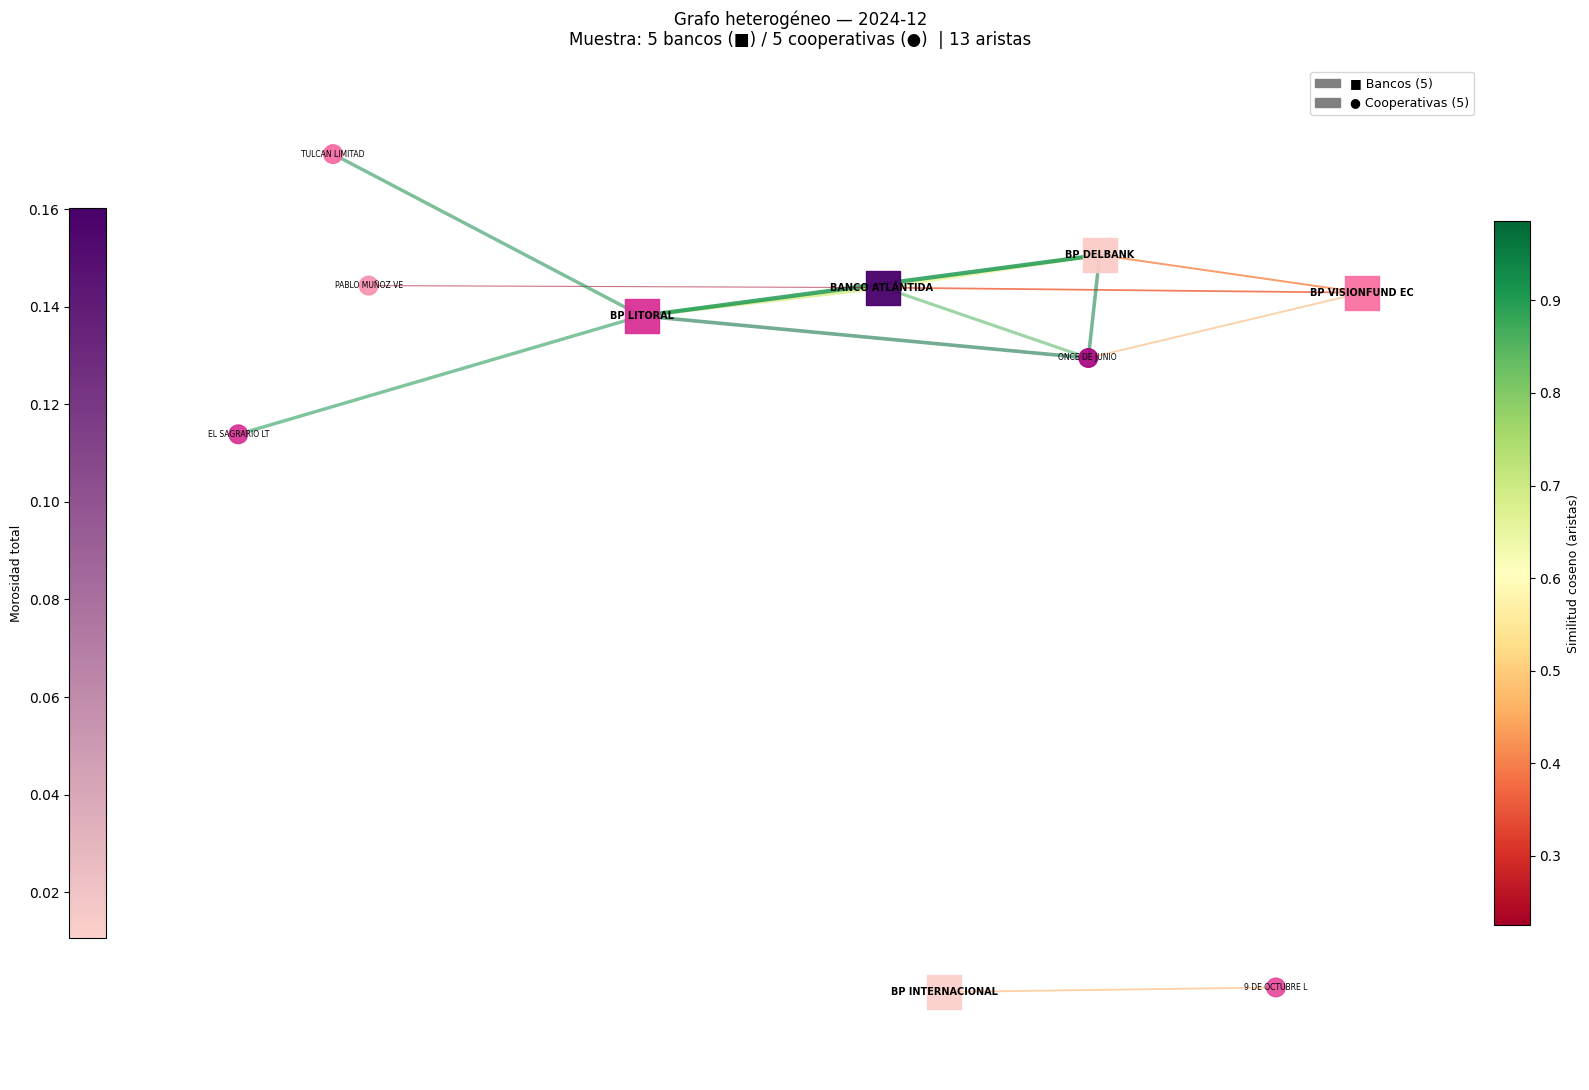

In [59]:
def visualizar_snapshot(snapshot, fecha, max_nodos_banco=15, max_nodos_coop=30):
    """
    Visualiza una muestra del grafo de un snapshot donde:
    - Color de nodo refleja morosidad con escala unificada (RdPu) para bancos y coops
    - Forma distingue el tipo: bancos = cuadrados (más grandes), coops = círculos
    - Color y grosor de arista refleja similitud coseno (RdYlGn)
    """
    G = nx.Graph()

    mask_b   = snapshot['banco'].mask.numpy()
    mask_c   = snapshot['cooperativa'].mask.numpy()
    y_b_full = snapshot['banco'].y.numpy()
    y_c_full = snapshot['cooperativa'].y.numpy()

    # ── Muestra aleatoria de nodos activos ────────────────────────────────────
    bancos_act_todos = [bancos_universo[i] for i in range(N_BANCOS) if mask_b[i]]
    coops_act_todos  = [coops_universo[i]  for i in range(N_COOPS)  if mask_c[i]]

    rng = np.random.default_rng(seed=42)
    bancos_muestra = rng.choice(bancos_act_todos,
                                size=min(max_nodos_banco, len(bancos_act_todos)),
                                replace=False).tolist()
    coops_muestra  = rng.choice(coops_act_todos,
                                size=min(max_nodos_coop, len(coops_act_todos)),
                                replace=False).tolist()

    bancos_idx_set = set(banco2idx[b] for b in bancos_muestra)
    coops_idx_set  = set(coop2idx[c]  for c in coops_muestra)

    # ── Agregar nodos ─────────────────────────────────────────────────────────
    for b in bancos_muestra:
        G.add_node(f'B_{b}', tipo='banco', mora=y_b_full[banco2idx[b]])
    for c in coops_muestra:
        G.add_node(f'C_{c}', tipo='cooperativa', mora=y_c_full[coop2idx[c]])

    # ── Aristas banco-banco ───────────────────────────────────────────────────
    ei_bb = snapshot['banco', 'similar_a', 'banco'].edge_index.numpy()
    ea_bb = snapshot['banco', 'similar_a', 'banco'].edge_attr.numpy().flatten()
    edges_bb, weights_bb = [], []
    for i in range(ei_bb.shape[1]):
        s, t = ei_bb[0, i], ei_bb[1, i]
        if s in bancos_idx_set and t in bancos_idx_set:
            ns, nt = f'B_{bancos_universo[s]}', f'B_{bancos_universo[t]}'
            if not G.has_edge(ns, nt):
                G.add_edge(ns, nt, sim=float(ea_bb[i]), tipo='bb')
                edges_bb.append((ns, nt))
                weights_bb.append(float(ea_bb[i]))

    # ── Aristas banco-coop ────────────────────────────────────────────────────
    ei_bc = snapshot['banco', 'relacionado_con', 'cooperativa'].edge_index.numpy()
    ea_bc = snapshot['banco', 'relacionado_con', 'cooperativa'].edge_attr.numpy().flatten()
    edges_bc, weights_bc = [], []
    for i in range(ei_bc.shape[1]):
        b_idx, c_idx = ei_bc[0, i], ei_bc[1, i]
        if b_idx in bancos_idx_set and c_idx in coops_idx_set:
            nb = f'B_{bancos_universo[b_idx]}'
            nc = f'C_{coops_universo[c_idx]}'
            if not G.has_edge(nb, nc):
                G.add_edge(nb, nc, sim=float(ea_bc[i]), tipo='bc')
                edges_bc.append((nb, nc))
                weights_bc.append(float(ea_bc[i]))

    # ── Layout ────────────────────────────────────────────────────────────────
    pos = nx.spring_layout(G, seed=42, k=0.6)

    fig, ax = plt.subplots(figsize=(16, 11))

    # ── Colormaps ─────────────────────────────────────────────────────────────
    cmap_mora = cm.RdPu    # un solo colormap para morosidad de todos los nodos
    cmap_edge = cm.RdYlGn  # aristas por similitud coseno

    # Normalización de morosidad unificada sobre todos los nodos de la muestra
    mora_vals = np.array([G.nodes[n]['mora'] for n in G.nodes])
    mora_norm = mcolors.Normalize(vmin=mora_vals.min(), vmax=mora_vals.max())

    # Normalización de similitud sobre rango real de la muestra
    all_weights = weights_bb + weights_bc
    sim_norm = mcolors.Normalize(
        vmin=min(all_weights) if all_weights else 0,
        vmax=max(all_weights) if all_weights else 1
    )

    # ── Dibujar aristas ───────────────────────────────────────────────────────
    def dibujar_aristas(edges, weights, alpha, width_scale):
        if not edges:
            return
        colores = [cmap_edge(sim_norm(w)) for w in weights]
        widths  = [0.8 + width_scale * sim_norm(w) for w in weights]
        nx.draw_networkx_edges(
            G, pos, edgelist=edges,
            edge_color=colores, width=widths,
            alpha=alpha, ax=ax
        )

    dibujar_aristas(edges_bb, weights_bb, alpha=0.85, width_scale=2.5)
    dibujar_aristas(edges_bc, weights_bc, alpha=0.55, width_scale=1.8)

    # ── Dibujar nodos: bancos y coops con el mismo colormap ───────────────────
    nodos_b = [n for n in G.nodes if G.nodes[n]['tipo'] == 'banco']
    nodos_c = [n for n in G.nodes if G.nodes[n]['tipo'] == 'cooperativa']

    # Clamp a [0.2, 1.0] para evitar colores demasiado claros con mora=0
    def color_mora(n):
        return cmap_mora(0.2 + 0.8 * mora_norm(G.nodes[n]['mora']))

    colores_b = [color_mora(n) for n in nodos_b]
    colores_c = [color_mora(n) for n in nodos_c]

    # Bancos como cuadrados (marker='s') para distinguirlos visualmente del tipo
    # sin necesidad de colores distintos
    nx.draw_networkx_nodes(G, pos, nodelist=nodos_b,
                           node_color=colores_b, node_size=600,
                           node_shape='s',   # cuadrado
                           alpha=0.95, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=nodos_c,
                           node_color=colores_c, node_size=180,
                           node_shape='o',   # círculo
                           alpha=0.90, ax=ax)

    # ── Etiquetas para bancos Y cooperativas ──────────────────────────────────
    labels_b = {n: n.replace('B_', '')[:16]  for n in nodos_b}
    labels_c = {n: n.replace('C_', '')[:14]  for n in nodos_c}

    nx.draw_networkx_labels(G, pos, labels=labels_b,
                            font_size=7, font_weight='bold', ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels_c,
                            font_size=5.5, font_weight='normal', ax=ax)

    # ── Título ────────────────────────────────────────────────────────────────
    ax.set_title(
        f'Grafo heterogéneo — {fecha.strftime("%Y-%m")}\n'
        f'Muestra: {len(nodos_b)} bancos (■) / {len(nodos_c)} cooperativas (●)  '
        f'| {G.number_of_edges()} aristas',
        fontsize=12, pad=15
    )
    ax.axis('off')

    # ── Colorbar morosidad (unificada) ────────────────────────────────────────
    sm_mora = cm.ScalarMappable(
        cmap=mcolors.LinearSegmentedColormap.from_list(
            'RdPu_clamped', [cmap_mora(0.2), cmap_mora(1.0)]
        ),
        norm=mora_norm
    )
    sm_mora.set_array([])
    cbar_mora = plt.colorbar(sm_mora, ax=ax, fraction=0.025, pad=0.01, location='left')
    cbar_mora.set_label('Morosidad total', fontsize=9)

    # ── Colorbar similitud aristas ────────────────────────────────────────────
    sm_edge = cm.ScalarMappable(cmap=cmap_edge, norm=sim_norm)
    sm_edge.set_array([])
    cbar_e = plt.colorbar(sm_edge, ax=ax, fraction=0.025, pad=0.01)
    cbar_e.set_label('Similitud coseno (aristas)', fontsize=9)

    # ── Leyenda de forma de nodo ──────────────────────────────────────────────
    patch_b = mpatches.Patch(color='gray', label=f'■ Bancos ({len(nodos_b)})')
    patch_c = mpatches.Patch(color='gray', label=f'● Cooperativas ({len(nodos_c)})')
    ax.legend(handles=[patch_b, patch_c], loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()


# Visualizar
visualizar_snapshot(snapshots[periodos[-10]], periodos[-10], max_nodos_banco=5, max_nodos_coop=5)

Bancos fijos seleccionados (10): ['BP LOJA', 'BP DELBANK', 'BP CITIBANK', 'BP COOPNACIONAL', 'BP PICHINCHA', 'BP GUAYAQUIL', 'BP VISIONFUND ECUADOR S.A.', 'BANCO AMIBANK S.A.', 'BP SOLIDARIO', 'BP AUSTRO']
Coops fijas seleccionadas  (15): ['ONCE DE JUNIO LTDA', 'ANDALUCIA LIMITADA', 'DE LA PEQUEÑA EMPRESA BIBLIAN LIMITADA', 'ALFONSO JARAMILLO LEON CAJA', '9 DE OCTUBRE LTDA']...


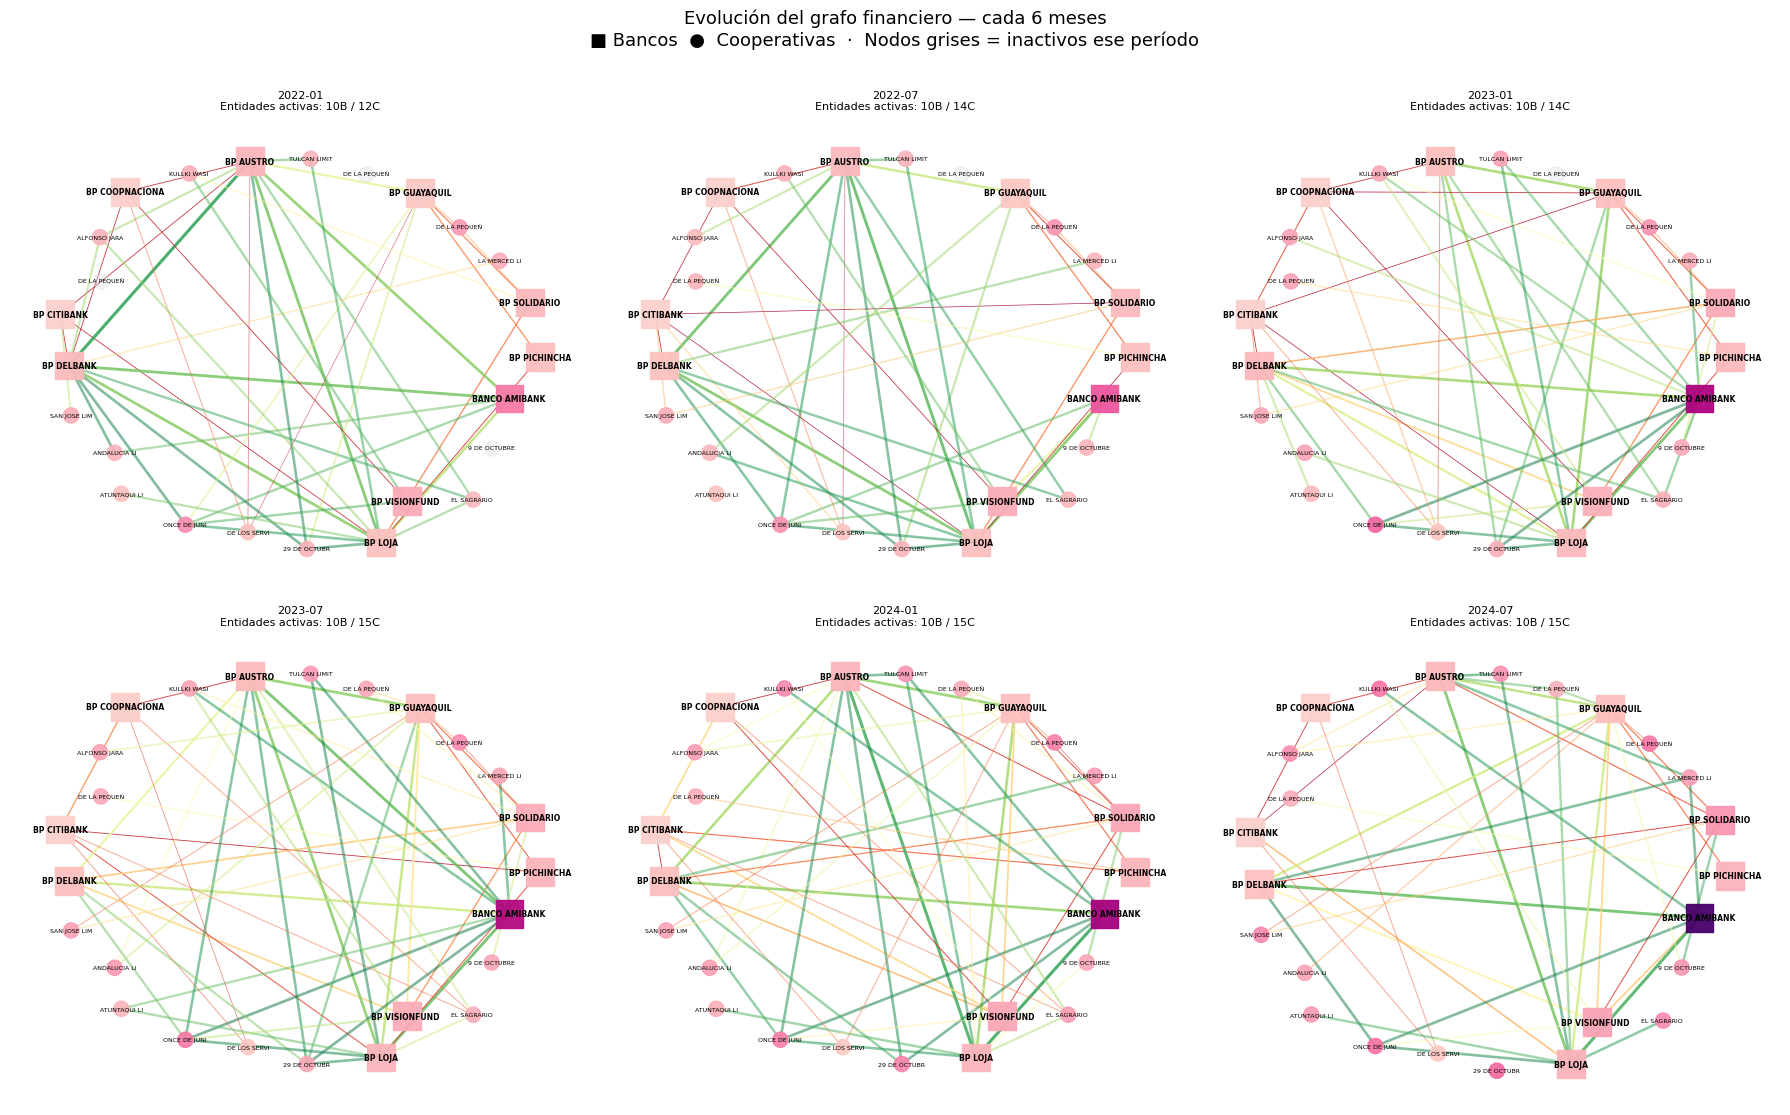

In [82]:
def visualizar_evolucion_grafo(snapshots, periodos, cada_n_meses=6,
                                max_nodos_banco=10, max_nodos_coop=20,
                                seed=42):
    """
    Muestra la evolución del grafo a lo largo del tiempo con un conjunto
    FIJO de entidades seleccionadas al inicio, para que sean comparables
    entre períodos. Si una entidad no estuvo activa en un período, su nodo
    aparece atenuado y sin aristas.
    """
    periodos_sel = periodos[::cada_n_meses]

    # ── Seleccionar entidades fijas: las más frecuentes en los períodos ────────
    # Para que la muestra sea representativa, se eligen las entidades que
    # aparecen en más períodos (más "estables" en el tiempo)
    rng = np.random.default_rng(seed=seed)

    bancos_disponibles = [b for b in bancos_universo
                          if any(snapshots[f]['banco'].mask.numpy()[banco2idx[b]]
                                 for f in periodos_sel)]
    coops_disponibles  = [c for c in coops_universo
                          if any(snapshots[f]['cooperativa'].mask.numpy()[coop2idx[c]]
                                 for f in periodos_sel)]

    bancos_fijos = rng.choice(bancos_disponibles,
                              size=min(max_nodos_banco, len(bancos_disponibles)),
                              replace=False).tolist()
    coops_fijas  = rng.choice(coops_disponibles,
                              size=min(max_nodos_coop, len(coops_disponibles)),
                              replace=False).tolist()

    bancos_idx_set = set(banco2idx[b] for b in bancos_fijos)
    coops_idx_set  = set(coop2idx[c]  for c in coops_fijas)

    print(f'Bancos fijos seleccionados ({len(bancos_fijos)}): {bancos_fijos}')
    print(f'Coops fijas seleccionadas  ({len(coops_fijas)}): {coops_fijas[:5]}...')

    n_panels = len(periodos_sel)
    n_cols   = min(3, n_panels)
    n_rows   = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 5.5 * n_rows))
    axes = np.array(axes).flatten()

    # ── Rango global de morosidad y similitud para escala consistente ──────────
    all_mora, all_sim = [], []
    for f in periodos_sel:
        snap   = snapshots[f]
        mask_b = snap['banco'].mask.numpy()
        mask_c = snap['cooperativa'].mask.numpy()
        for b in bancos_fijos:
            idx = banco2idx[b]
            if mask_b[idx]:
                all_mora.append(snap['banco'].y.numpy()[idx])
        for c in coops_fijas:
            idx = coop2idx[c]
            if mask_c[idx]:
                all_mora.append(snap['cooperativa'].y.numpy()[idx])
        for rel in [('banco', 'similar_a', 'banco'),
                    ('banco', 'relacionado_con', 'cooperativa')]:
            all_sim.extend(snap[rel].edge_attr.numpy().flatten().tolist())

    mora_norm_global = mcolors.Normalize(vmin=np.min(all_mora), vmax=np.max(all_mora))
    sim_norm_global  = mcolors.Normalize(
        vmin=np.min(all_sim) if all_sim else 0,
        vmax=np.max(all_sim) if all_sim else 1
    )

    cmap_mora = cm.RdPu
    cmap_edge = cm.RdYlGn

    # ── Layout fijo: calculado con el último período para máxima actividad ─────
    # Se construye una vez y se reutiliza en todos los paneles
    G_layout = nx.Graph()
    for b in bancos_fijos:
        G_layout.add_node(f'B_{b}')
    for c in coops_fijas:
        G_layout.add_node(f'C_{c}')
    pos_fijo = nx.spring_layout(G_layout, seed=seed, k=0.7)

    # ── Dibujar cada panel ────────────────────────────────────────────────────
    for ax_idx, fecha in enumerate(periodos_sel):
        ax   = axes[ax_idx]
        snap = snapshots[fecha]

        mask_b   = snap['banco'].mask.numpy()
        mask_c   = snap['cooperativa'].mask.numpy()
        y_b_full = snap['banco'].y.numpy()
        y_c_full = snap['cooperativa'].y.numpy()

        # Clasificar entidades fijas en activas/inactivas este período
        bancos_activos_panel = [b for b in bancos_fijos if mask_b[banco2idx[b]]]
        bancos_inactivos_panel = [b for b in bancos_fijos if not mask_b[banco2idx[b]]]
        coops_activas_panel  = [c for c in coops_fijas  if mask_c[coop2idx[c]]]
        coops_inactivas_panel = [c for c in coops_fijas if not mask_c[coop2idx[c]]]

        bancos_activos_idx = set(banco2idx[b] for b in bancos_activos_panel)
        coops_activas_idx  = set(coop2idx[c]  for c in coops_activas_panel)

        # Construir grafo del período con entidades fijas
        G = nx.Graph()
        for b in bancos_fijos:
            G.add_node(f'B_{b}', tipo='banco',
                       mora=y_b_full[banco2idx[b]],
                       activo=mask_b[banco2idx[b]])
        for c in coops_fijas:
            G.add_node(f'C_{c}', tipo='cooperativa',
                       mora=y_c_full[coop2idx[c]],
                       activo=mask_c[coop2idx[c]])

        # Aristas banco-banco (solo entre activos)
        ei_bb = snap['banco', 'similar_a', 'banco'].edge_index.numpy()
        ea_bb = snap['banco', 'similar_a', 'banco'].edge_attr.numpy().flatten()
        edges_bb, weights_bb = [], []
        for i in range(ei_bb.shape[1]):
            s, t = ei_bb[0, i], ei_bb[1, i]
            if s in bancos_activos_idx and t in bancos_activos_idx \
               and s in bancos_idx_set and t in bancos_idx_set:
                ns, nt = f'B_{bancos_universo[s]}', f'B_{bancos_universo[t]}'
                if not G.has_edge(ns, nt):
                    G.add_edge(ns, nt)
                    edges_bb.append((ns, nt))
                    weights_bb.append(float(ea_bb[i]))

        # Aristas banco-coop (solo entre activos)
        ei_bc = snap['banco', 'relacionado_con', 'cooperativa'].edge_index.numpy()
        ea_bc = snap['banco', 'relacionado_con', 'cooperativa'].edge_attr.numpy().flatten()
        edges_bc, weights_bc = [], []
        for i in range(ei_bc.shape[1]):
            b_idx, c_idx = ei_bc[0, i], ei_bc[1, i]
            if b_idx in bancos_activos_idx and c_idx in coops_activas_idx \
               and b_idx in bancos_idx_set and c_idx in coops_idx_set:
                nb = f'B_{bancos_universo[b_idx]}'
                nc = f'C_{coops_universo[c_idx]}'
                if not G.has_edge(nb, nc):
                    G.add_edge(nb, nc)
                    edges_bc.append((nb, nc))
                    weights_bc.append(float(ea_bc[i]))

        # ── Dibujar aristas ───────────────────────────────────────────────────
        def dibujar_aristas_panel(edges, weights, alpha, width_scale):
            if not edges:
                return
            colores = [cmap_edge(sim_norm_global(w)) for w in weights]
            widths  = [0.5 + width_scale * sim_norm_global(w) for w in weights]
            nx.draw_networkx_edges(G, pos_fijo, edgelist=edges,
                                   edge_color=colores, width=widths,
                                   alpha=alpha, ax=ax)

        dibujar_aristas_panel(edges_bb, weights_bb, alpha=0.85, width_scale=2.0)
        dibujar_aristas_panel(edges_bc, weights_bc, alpha=0.50, width_scale=1.5)

        # ── Dibujar nodos activos ─────────────────────────────────────────────
        def color_mora(n):
            return cmap_mora(0.2 + 0.8 * mora_norm_global(G.nodes[n]['mora']))

        nodos_b_act = [f'B_{b}' for b in bancos_activos_panel]
        nodos_c_act = [f'C_{c}' for c in coops_activas_panel]
        nodos_b_inact = [f'B_{b}' for b in bancos_inactivos_panel]
        nodos_c_inact = [f'C_{c}' for c in coops_inactivas_panel]

        # Activos: coloreados por morosidad
        nx.draw_networkx_nodes(G, pos_fijo, nodelist=nodos_b_act,
                               node_color=[color_mora(n) for n in nodos_b_act],
                               node_size=400, node_shape='s', alpha=0.95, ax=ax)
        nx.draw_networkx_nodes(G, pos_fijo, nodelist=nodos_c_act,
                               node_color=[color_mora(n) for n in nodos_c_act],
                               node_size=120, node_shape='o', alpha=0.90, ax=ax)

        # Inactivos: gris y transparentes
        if nodos_b_inact:
            nx.draw_networkx_nodes(G, pos_fijo, nodelist=nodos_b_inact,
                                   node_color='#D5D8DC', node_size=400,
                                   node_shape='s', alpha=0.3, ax=ax)
        if nodos_c_inact:
            nx.draw_networkx_nodes(G, pos_fijo, nodelist=nodos_c_inact,
                                   node_color='#D5D8DC', node_size=120,
                                   node_shape='o', alpha=0.3, ax=ax)

        # ── Etiquetas ─────────────────────────────────────────────────────────
        labels_b = {f'B_{b}': b[:14] for b in bancos_fijos}
        labels_c = {f'C_{c}': c[:12] for c in coops_fijas}
        nx.draw_networkx_labels(G, pos_fijo, labels=labels_b,
                                font_size=5.5, font_weight='bold', ax=ax)
        nx.draw_networkx_labels(G, pos_fijo, labels=labels_c,
                                font_size=4.5, ax=ax)

        # ── Título del panel ──────────────────────────────────────────────────
        mora_b = np.mean([y_b_full[banco2idx[b]] for b in bancos_activos_panel]) \
                 if bancos_activos_panel else 0
        mora_c = np.mean([y_c_full[coop2idx[c]] for c in coops_activas_panel]) \
                 if coops_activas_panel else 0

        ax.set_title(
            f'{fecha.strftime("%Y-%m")}\n'
            f'Entidades activas: {len(bancos_activos_panel)}B / {len(coops_activas_panel)}C',
            fontsize=8, pad=6
        )
        ax.axis('off')

    # Ocultar paneles vacíos
    for ax_idx in range(len(periodos_sel), len(axes)):
        axes[ax_idx].axis('off')

    # ── Colorbars globales ────────────────────────────────────────────────────
    sm_mora = cm.ScalarMappable(
        cmap=mcolors.LinearSegmentedColormap.from_list(
            'RdPu_clamped', [cmap_mora(0.2), cmap_mora(1.0)]
        ),
        norm=mora_norm_global
    )
    sm_mora.set_array([])
    # fig.colorbar(sm_mora, ax=axes[:len(periodos_sel)],
    #              fraction=0.012, pad=0.01, location='left').set_label('Morosidad total', fontsize=10)

    sm_edge = cm.ScalarMappable(cmap=cmap_edge, norm=sim_norm_global)
    sm_edge.set_array([])
    # fig.colorbar(sm_edge, ax=axes[:len(periodos_sel)],
    #              fraction=0.012, pad=0.01).set_label('Similitud coseno (aristas)', fontsize=10)

    fig.suptitle(
        f'Evolución del grafo financiero — cada {cada_n_meses} meses\n'
        f'■ Bancos  ●  Cooperativas  ·  Nodos grises = inactivos ese período',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()


# Llamada
periodos_sub = [p for p in periodos if p >= pd.Timestamp('2022-01-01') and p <= pd.Timestamp('2025-01-01')]
visualizar_evolucion_grafo(snapshots, periodos_sub, cada_n_meses=6, max_nodos_banco=10, max_nodos_coop=15, seed=52)

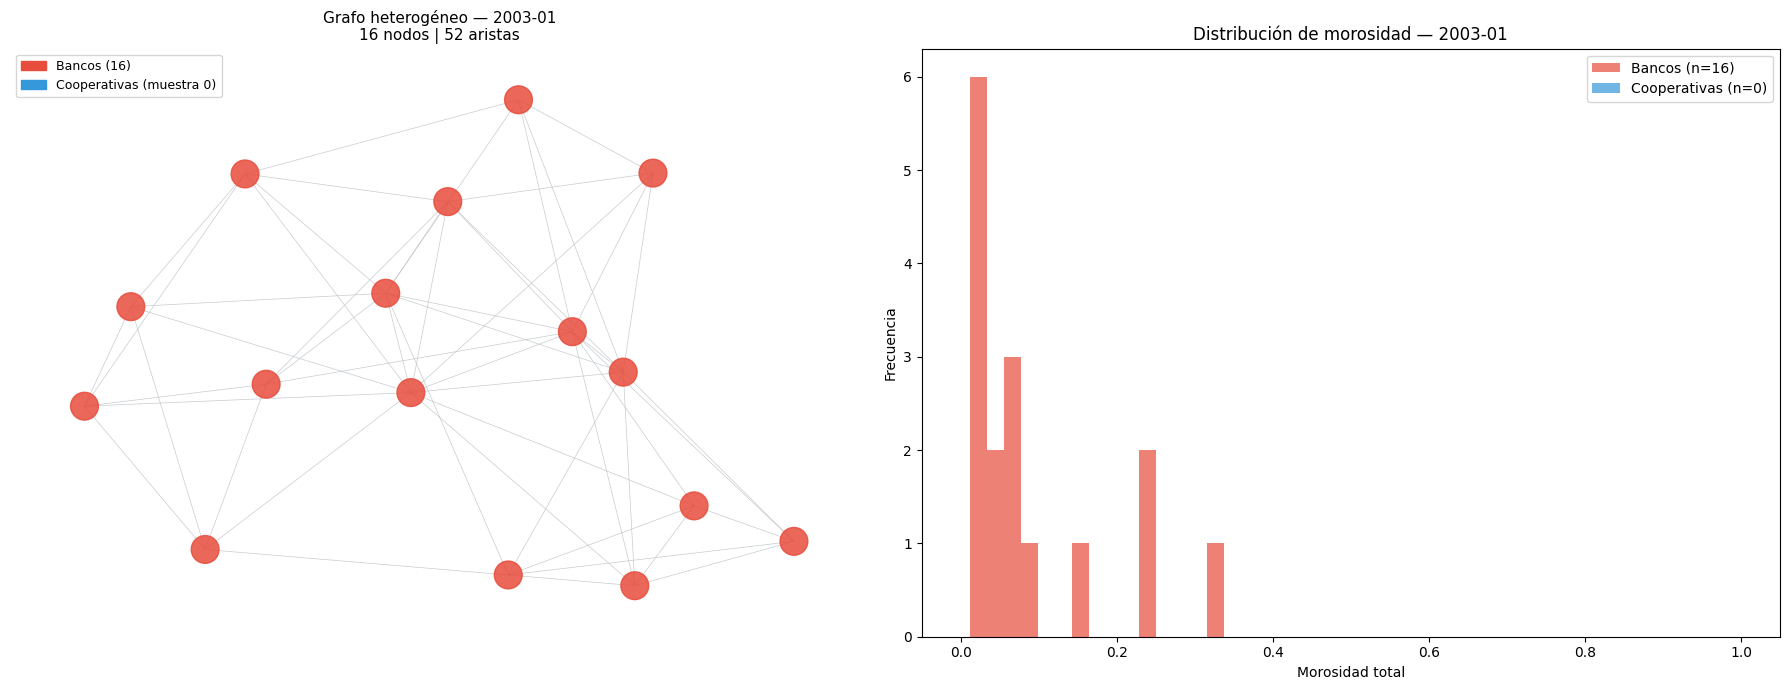

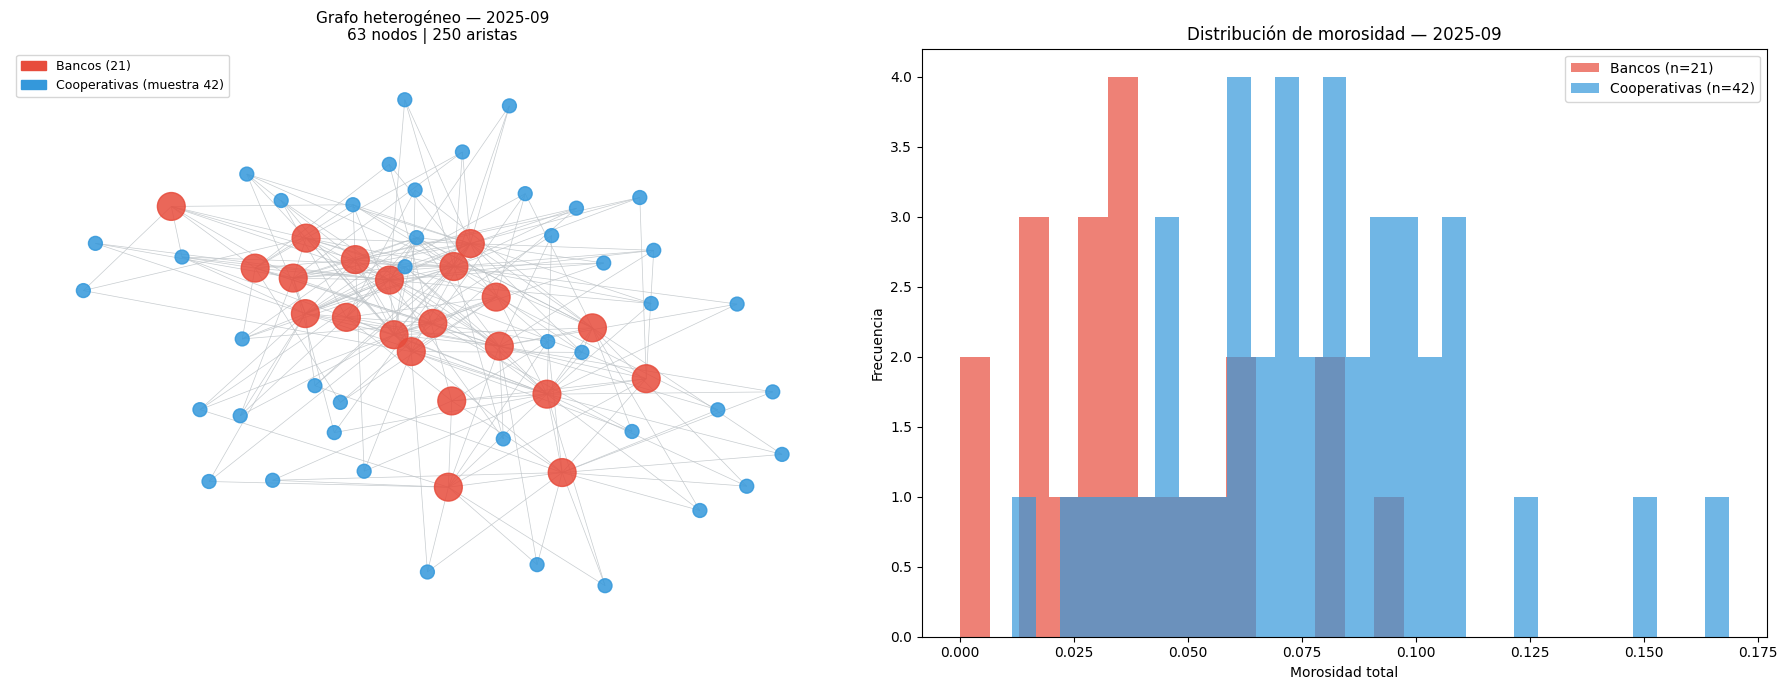

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import seaborn as sns

def visualizar_snapshot(snapshot, fecha, max_nodos_coop=50):
    """
    Visualiza el grafo de un snapshot mostrando todos los bancos
    y una muestra de cooperativas activas.
    """
    G = nx.Graph()

    # Nodos banco activos
    mask_b = snapshot['banco'].mask.numpy()
    bancos_act = [bancos_universo[i] for i in range(N_BANCOS) if mask_b[i]]
    for b in bancos_act:
        G.add_node(f'B_{b}', tipo='banco')

    # Nodos cooperativa activos (muestra)
    mask_c = snapshot['cooperativa'].mask.numpy()
    coops_act = [coops_universo[i] for i in range(N_COOPS) if mask_c[i]][:max_nodos_coop]
    coops_idx  = [coop2idx[c] for c in coops_act]
    for c in coops_act:
        G.add_node(f'C_{c}', tipo='cooperativa')

    # Aristas banco-banco
    ei_bb = snapshot['banco', 'similar_a', 'banco'].edge_index.numpy()
    for i in range(ei_bb.shape[1]):
        s, t = ei_bb[0, i], ei_bb[1, i]
        if mask_b[s] and mask_b[t]:
            G.add_edge(f'B_{bancos_universo[s]}', f'B_{bancos_universo[t]}', tipo='bb')

    # Aristas banco-coop (solo las que involucran coops en la muestra)
    ei_bc = snapshot['banco', 'relacionado_con', 'cooperativa'].edge_index.numpy()
    coop_idx_set = set(coops_idx)
    for i in range(ei_bc.shape[1]):
        b_idx, c_idx = ei_bc[0, i], ei_bc[1, i]
        if mask_b[b_idx] and c_idx in coop_idx_set:
            G.add_edge(f'B_{bancos_universo[b_idx]}', f'C_{coops_universo[c_idx]}', tipo='bc')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # ── Grafo ──────────────────────────────────────────────────────────────────
    ax = axes[0]
    color_map = ['#E74C3C' if G.nodes[n]['tipo'] == 'banco' else '#3498DB' for n in G.nodes]
    size_map  = [400 if G.nodes[n]['tipo'] == 'banco' else 100 for n in G.nodes]
    pos = nx.spring_layout(G, seed=42, k=0.5)
    nx.draw(G, pos, ax=ax, node_color=color_map, node_size=size_map,
            alpha=0.85, with_labels=False, edge_color='#BDC3C7', width=0.5)

    patch_b = mpatches.Patch(color='#E74C3C', label=f'Bancos ({len(bancos_act)})')
    patch_c = mpatches.Patch(color='#3498DB', label=f'Cooperativas (muestra {len(coops_act)})')
    ax.legend(handles=[patch_b, patch_c], loc='upper left', fontsize=9)
    ax.set_title(f'Grafo heterogéneo — {fecha.strftime("%Y-%m")}\n'
                 f'{G.number_of_nodes()} nodos | {G.number_of_edges()} aristas', fontsize=11)

    # ── Distribución de morosidad ──────────────────────────────────────────────
    ax2 = axes[1]
    y_b = snapshot['banco'].y.numpy()[mask_b]
    y_c = snapshot['cooperativa'].y.numpy()[mask_c]
    ax2.hist(y_b, bins=15, alpha=0.7, color='#E74C3C', label=f'Bancos (n={len(y_b)})')
    ax2.hist(y_c, bins=30, alpha=0.7, color='#3498DB', label=f'Cooperativas (n={len(y_c)})')
    ax2.set_xlabel('Morosidad total')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title(f'Distribución de morosidad — {fecha.strftime("%Y-%m")}')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Visualizar primer y último período
visualizar_snapshot(snapshots[periodos[0]],  periodos[0])
visualizar_snapshot(snapshots[periodos[-1]], periodos[-1])

# Colocar nombres de los bancos y fuerza de la arista --------------------------

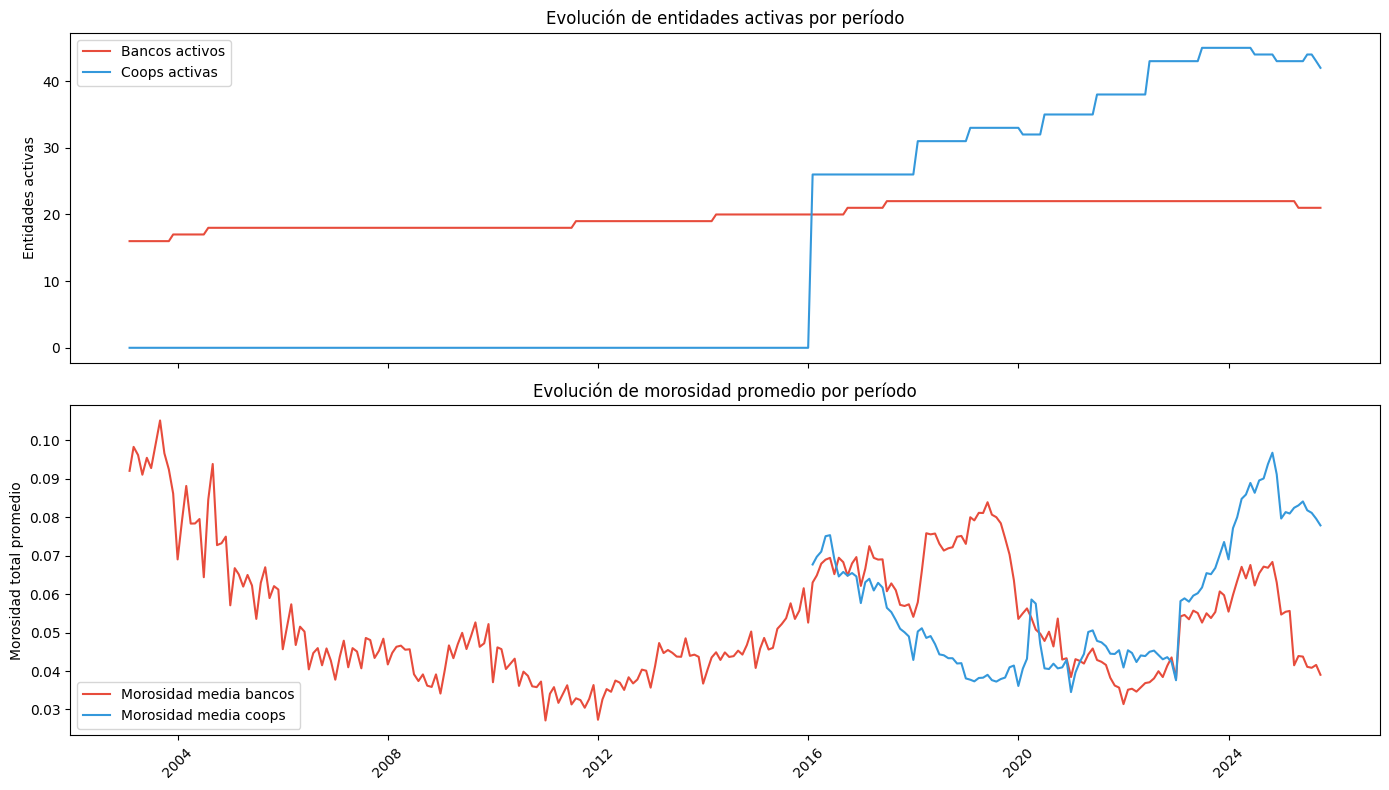

In [ ]:
# ── Evolución temporal de entidades activas y morosidad promedio ───────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

bancos_activos_t  = [snapshots[f]['banco'].mask.sum().item()        for f in periodos]
coops_activas_t   = [snapshots[f]['cooperativa'].mask.sum().item()  for f in periodos]
morosidad_banco_t = []
morosidad_coop_t  = []
for f in periodos:
    mb = snapshots[f]['banco'].mask.numpy()
    mc = snapshots[f]['cooperativa'].mask.numpy()
    yb = snapshots[f]['banco'].y.numpy()[mb]
    yc = snapshots[f]['cooperativa'].y.numpy()[mc]
    morosidad_banco_t.append(yb.mean() if len(yb) > 0 else np.nan)
    morosidad_coop_t.append(yc.mean()  if len(yc) > 0 else np.nan)

axes[0].plot(periodos, bancos_activos_t, color='#E74C3C', label='Bancos activos')
axes[0].plot(periodos, coops_activas_t,  color='#3498DB', label='Coops activas')
axes[0].set_ylabel('Entidades activas')
axes[0].set_title('Evolución de entidades activas por período')
axes[0].legend()

axes[1].plot(periodos, morosidad_banco_t, color='#E74C3C', label='Morosidad media bancos')
axes[1].plot(periodos, morosidad_coop_t,  color='#3498DB', label='Morosidad media coops')
axes[1].set_ylabel('Morosidad total promedio')
axes[1].set_title('Evolución de morosidad promedio por período')
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Dataset con ventanas deslizantes

In [ ]:
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 6   # usar 6 meses de historia para predecir el siguiente

class FinancialGraphDataset(Dataset):
    """
    Cada muestra es una secuencia de SEQ_LEN snapshots (X)
    y el snapshot siguiente como target (y).
    El target es la morosidad de cada nodo en t+1.
    """
    def __init__(self, lista_periodos, snapshots_dict, seq_len):
        self.seq_len = seq_len
        self.samples = []
        for i in range(len(lista_periodos) - seq_len):
            seq_fechas  = lista_periodos[i : i + seq_len]
            target_fecha = lista_periodos[i + seq_len]
            self.samples.append((seq_fechas, target_fecha))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq_fechas, target_fecha = self.samples[idx]
        seq_snapshots = [snapshots[f] for f in seq_fechas]
        target_snap   = snapshots[target_fecha]
        return seq_snapshots, target_snap

# Cada split tiene sus propios períodos
# Se incluye SEQ_LEN períodos de overlap al inicio de val/test
periodos_val_ext  = periodos[n_train - SEQ_LEN : n_train + n_val]
periodos_test_ext = periodos[n_train + n_val - SEQ_LEN :]

train_dataset = FinancialGraphDataset(periodos_train, snapshots, SEQ_LEN)
val_dataset   = FinancialGraphDataset(periodos_val_ext,  snapshots, SEQ_LEN)
test_dataset  = FinancialGraphDataset(periodos_test_ext, snapshots, SEQ_LEN)

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')
print(f'Test  samples : {len(test_dataset)}')

# DataLoader con batch_size=1
# collate_fn personalizado para no hacer padding de grafos
def collate_fn(batch):
    return batch  # lista de (seq_snapshots, target_snap)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, collate_fn=collate_fn)

print('\nDataLoaders listos')

Train samples : 212
Val   samples : 27
Test  samples : 28

DataLoaders listos


## Definición del modelo HeteroGAT + LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HGTConv, Linear

# Metadata del grafo heterogéneo (tipos de nodo y arista)
NODE_TYPES = ['banco', 'cooperativa']
EDGE_TYPES = [
    ('banco',        'similar_a',       'banco'),
    ('cooperativa',  'similar_a',       'cooperativa'),
    ('banco',        'relacionado_con', 'cooperativa'),
    ('cooperativa',  'relacionado_con', 'banco'),
]
METADATA = (NODE_TYPES, EDGE_TYPES)


class HeteroGraphLSTM(nn.Module):
    """
    Arquitectura:
      1. Proyección lineal por tipo de nodo al espacio latente común
      2. N capas HGTConv (message passing heterogéneo)
      3. Concatenación de embeddings de todos los nodos
      4. LSTM sobre la secuencia temporal de grafos
      5. FC separados por tipo de nodo → predicción de morosidad
    """
    def __init__(
        self,
        dim_banco:   int,   # features de entrada banco
        dim_coop:    int,   # features de entrada cooperativa
        hidden_gnn:  int = 32,   # dimensión espacio latente GNN
        n_gnn_layers: int = 2,   # capas HGTConv
        n_heads:     int = 4,    # cabezas de atención HGT
        hidden_lstm: int = 64,   # dimensión oculta LSTM
        n_lstm_layers: int = 2,
        dropout:     float = 0.2,
        n_bancos:    int = N_BANCOS,
        n_coops:     int = N_COOPS,
    ):
        super().__init__()
        self.hidden_gnn   = hidden_gnn
        self.n_bancos     = n_bancos
        self.n_coops      = n_coops
        self.total_nodos  = n_bancos + n_coops
        self.n_gnn_layers = n_gnn_layers

        # ── Proyecciones de entrada (resuelve asimetría de features) ───────────
        self.proj_banco = nn.Sequential(
            Linear(dim_banco, hidden_gnn),
            nn.LayerNorm(hidden_gnn),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.proj_coop = nn.Sequential(
            Linear(dim_coop, hidden_gnn),
            nn.LayerNorm(hidden_gnn),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Capas HGTConv ──────────────────────────────────────────────────────
        self.hgt_layers = nn.ModuleList([
            HGTConv(
                in_channels=hidden_gnn,
                out_channels=hidden_gnn,
                metadata=METADATA,
                heads=n_heads,
            )
            for _ in range(n_gnn_layers)
        ])
        self.layer_norms = nn.ModuleList([
            nn.ModuleDict({
                'banco': nn.LayerNorm(hidden_gnn),
                'cooperativa': nn.LayerNorm(hidden_gnn)
            })
            for _ in range(n_gnn_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        # ── LSTM ───────────────────────────────────────────────────────────────
        # Input: (total_nodos * hidden_gnn) por timestep
        lstm_input_dim  = self.total_nodos * hidden_gnn
        lstm_hidden_dim = self.total_nodos * hidden_lstm
        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=n_lstm_layers,
            batch_first=True,
            dropout=dropout if n_lstm_layers > 1 else 0.0
        )

        # ── Cabezas de predicción por tipo ─────────────────────────────────────
        self.fc_banco = nn.Sequential(
            nn.Linear(hidden_lstm, hidden_lstm // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_lstm // 2, 1)
        )
        self.fc_coop = nn.Sequential(
            nn.Linear(hidden_lstm, hidden_lstm // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_lstm // 2, 1)
        )

        self.hidden_lstm = hidden_lstm

    def forward(self, seq_snapshots: list):
        """
        seq_snapshots: lista de HeteroData de longitud SEQ_LEN
        Retorna:
          pred_banco : (N_BANCOS,)  predicción de morosidad
          pred_coop  : (N_COOPS,)   predicción de morosidad
        """
        gnn_outputs = []  # embeddings por timestep

        for snap in seq_snapshots:
            # ── Proyección de entrada ──────────────────────────────────────────
            x_dict = {
                'banco':        self.proj_banco(snap['banco'].x.to(device)),
                'cooperativa':  self.proj_coop(snap['cooperativa'].x.to(device)),
            }
            edge_index_dict = {
                etype: snap[etype].edge_index.to(device)
                for etype in EDGE_TYPES
                if snap[etype].edge_index.shape[1] > 0
            }

            # ── Message passing con skip connections ───────────────────────────
            for layer_idx, hgt in enumerate(self.hgt_layers):
                x_new = hgt(x_dict, edge_index_dict)
                # Skip connection + LayerNorm
                for ntype in x_dict:
                    if x_new.get(ntype) is not None:
                        x_dict[ntype] = self.layer_norms[layer_idx][ntype](
                            x_dict[ntype] + self.dropout(x_new[ntype])
                        )

            # ── Concatenar todos los nodos (banco primero, luego coop) ─────────
            # Shape: (total_nodos, hidden_gnn)
            node_emb = torch.cat([x_dict['banco'], x_dict['cooperativa']], dim=0)
            gnn_outputs.append(node_emb.view(-1))  # (total_nodos * hidden_gnn,)

        # ── LSTM: (1, seq_len, total_nodos * hidden_gnn) ──────────────────────
        lstm_input = torch.stack(gnn_outputs, dim=0).unsqueeze(0)  # (1, T, D)
        lstm_out, _ = self.lstm(lstm_input)
        last = lstm_out[:, -1, :]  # (1, total_nodos * hidden_lstm)

        # Reshape a (total_nodos, hidden_lstm)
        last = last.view(self.total_nodos, self.hidden_lstm)

        # ── Predicción por tipo de nodo ────────────────────────────────────────
        pred_banco = self.fc_banco(last[:self.n_bancos]).squeeze(-1)   # (N_BANCOS,)
        pred_coop  = self.fc_coop(last[self.n_bancos:]).squeeze(-1)    # (N_COOPS,)

        return pred_banco, pred_coop


# ─── Instanciar modelo ────────────────────────────────────────────────────────
model = HeteroGraphLSTM(
    dim_banco    = len(FEATURES_NODO_BANCO),
    dim_coop     = len(FEATURES_NODO_COOP),
    hidden_gnn   = 32,
    n_gnn_layers = 2,
    n_heads      = 4,
    hidden_lstm  = 32,
    n_lstm_layers= 2,
    dropout      = 0.2,
    n_bancos     = N_BANCOS,
    n_coops      = N_COOPS,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo instanciado en {device}')
print(f'Parámetros entrenables: {total_params:,}')
print()
print(model)

Modelo instanciado en cuda
Parámetros entrenables: 141,780,326

HeteroGraphLSTM(
  (proj_banco): Sequential(
    (0): Linear(82, 32, bias=True)
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (proj_coop): Sequential(
    (0): Linear(72, 32, bias=True)
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (hgt_layers): ModuleList(
    (0-1): 2 x HGTConv(-1, 32, heads=4)
  )
  (layer_norms): ModuleList(
    (0-1): 2 x ModuleDict(
      (banco): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (cooperativa): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(2976, 2976, num_layers=2, batch_first=True, dropout=0.2)
  (fc_banco): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(

In [ ]:
# ─── Test rápido de forward pass ──────────────────────────────────────────────
model.eval()
with torch.no_grad():
    seq_test = [snapshots[f] for f in periodos[:SEQ_LEN]]
    pred_b, pred_c = model(seq_test)
    print(f'Output banco      : {pred_b.shape}  →  esperado ({N_BANCOS},)')
    print(f'Output cooperativa: {pred_c.shape}  →  esperado ({N_COOPS},)')
print('Forward pass exitoso')

Output banco      : torch.Size([22])  →  esperado (22,)
Output cooperativa: torch.Size([71])  →  esperado (71,)
Forward pass exitoso


## Entrenamiento con Early Stopping

In [ ]:
import time

# ─── Hiperparámetros ──────────────────────────────────────────────────────────
EPOCHS        = 100
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15    # early stopping: épocas sin mejora

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7
)

def masked_mse(pred, target, mask):
    """MSE solo sobre nodos activos en el período."""
    if mask.sum() == 0:
        return torch.tensor(0.0, device=device)
    return F.mse_loss(pred[mask], target[mask])


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    n_samples  = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            seq_snapshots, target_snap = batch[0]  # batch_size=1

            pred_b, pred_c = model(seq_snapshots)

            # Target: morosidad del período siguiente
            y_b    = target_snap['banco'].y.to(device)
            y_c    = target_snap['cooperativa'].y.to(device)
            mask_b = target_snap['banco'].mask.to(device)
            mask_c = target_snap['cooperativa'].mask.to(device)

            loss_b = masked_mse(pred_b, y_b, mask_b)
            loss_c = masked_mse(pred_c, y_c, mask_c)
            loss   = loss_b + loss_c

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            n_samples  += 1

    return total_loss / max(n_samples, 1)


# ─── Loop de entrenamiento ────────────────────────────────────────────────────
history = {'train': [], 'val': []}
best_val_loss = float('inf')
best_epoch    = 0
patience_count = 0
CKPT_PATH = '/content/best_model.pt'

print(f'{"Epoch":>6} | {"Train MSE":>10} | {"Val MSE":>10} | {"Tiempo":>8}')
print('─' * 45)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    elapsed    = time.time() - t0

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    scheduler.step(val_loss)

    print(f'{epoch:6d} | {train_loss:10.5f} | {val_loss:10.5f} | {elapsed:7.1f}s')

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping en época {epoch}. Mejor época: {best_epoch}')
            break

print(f'\nMejor val MSE: {best_val_loss:.5f} (época {best_epoch})')

 Epoch |  Train MSE |    Val MSE |   Tiempo
─────────────────────────────────────────────
     1 |    0.00810 |    0.00385 |    50.6s
     2 |    0.00452 |    0.00346 |    49.8s
     3 |    0.00389 |    0.00252 |    50.0s
     4 |    0.00358 |    0.00247 |    49.9s
     5 |    0.00344 |    0.00203 |    50.1s
     6 |    0.00339 |    0.00221 |    50.0s
     7 |    0.00280 |    0.00412 |    50.2s
     8 |    0.00237 |    0.00695 |    50.4s
     9 |    0.00215 |    0.00341 |    50.5s
    10 |    0.00223 |    0.01102 |    50.7s
    11 |    0.00226 |    0.00856 |    50.1s
    12 |    0.00222 |    0.00473 |    50.4s
    13 |    0.00229 |    0.00869 |    51.1s
    14 |    0.00184 |    0.00830 |    50.7s
    15 |    0.00177 |    0.01302 |    50.6s
    16 |    0.00181 |    0.01142 |    51.0s
    17 |    0.00187 |    0.00977 |    50.0s
    18 |    0.00183 |    0.01026 |    50.5s
    19 |    0.00173 |    0.00902 |    50.5s
    20 |    0.00171 |    0.01054 |    50.5s

Early stopping en época 20. M

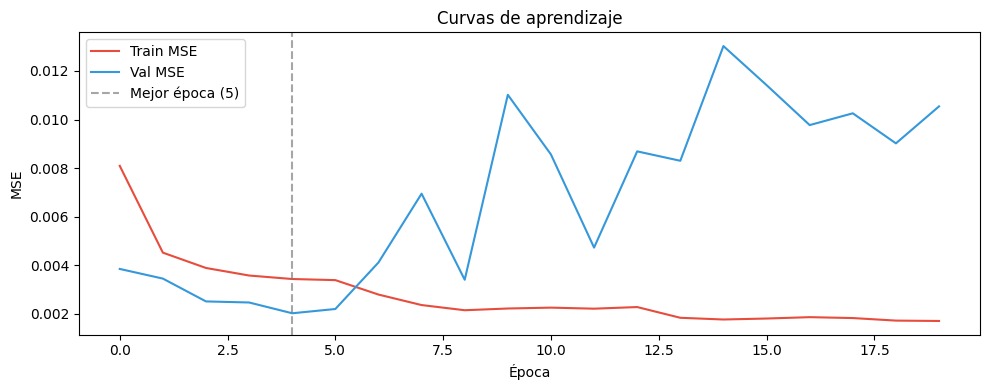

In [ ]:
# ─── Curvas de aprendizaje ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'], label='Train MSE', color='#E74C3C')
ax.plot(history['val'],   label='Val MSE',   color='#3498DB')
ax.axvline(best_epoch - 1, color='gray', linestyle='--', alpha=0.7, label=f'Mejor época ({best_epoch})')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.set_title('Curvas de aprendizaje')
ax.legend()
plt.tight_layout()
plt.show()

## Evaluación en test set

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Cargar mejor modelo
model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_pred_b, all_true_b, all_pred_c, all_true_c = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        seq_snapshots, target_snap = batch[0]
        pred_b, pred_c = model(seq_snapshots)

        mask_b = target_snap['banco'].mask.numpy()
        mask_c = target_snap['cooperativa'].mask.numpy()

        all_pred_b.append(pred_b.cpu().numpy()[mask_b])
        all_true_b.append(target_snap['banco'].y.numpy()[mask_b])
        all_pred_c.append(pred_c.cpu().numpy()[mask_c])
        all_true_c.append(target_snap['cooperativa'].y.numpy()[mask_c])

pred_b_all = np.concatenate(all_pred_b)
true_b_all = np.concatenate(all_true_b)
pred_c_all = np.concatenate(all_pred_c)
true_c_all = np.concatenate(all_true_c)

def metricas(pred, true, nombre):
    mse  = np.mean((pred - true) ** 2)
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(true, pred)
    print(f'── {nombre} ──')
    print(f'  MSE  : {mse:.5f}')
    print(f'  RMSE : {rmse:.5f}')
    print(f'  MAE  : {mae:.5f}')
    print(f'  R²   : {r2:.4f}')
    print()

metricas(pred_b_all, true_b_all, 'Bancos')
metricas(pred_c_all, true_c_all, 'Cooperativas')
metricas(
    np.concatenate([pred_b_all, pred_c_all]),
    np.concatenate([true_b_all, true_c_all]),
    'Total'
)

── Bancos ──
  MSE  : 0.00216
  RMSE : 0.04652
  MAE  : 0.02635
  R²   : 0.3025

── Cooperativas ──
  MSE  : 0.00461
  RMSE : 0.06788
  MAE  : 0.04799
  R²   : -2.5361

── Total ──
  MSE  : 0.00380
  RMSE : 0.06164
  MAE  : 0.04083
  R²   : -0.8733



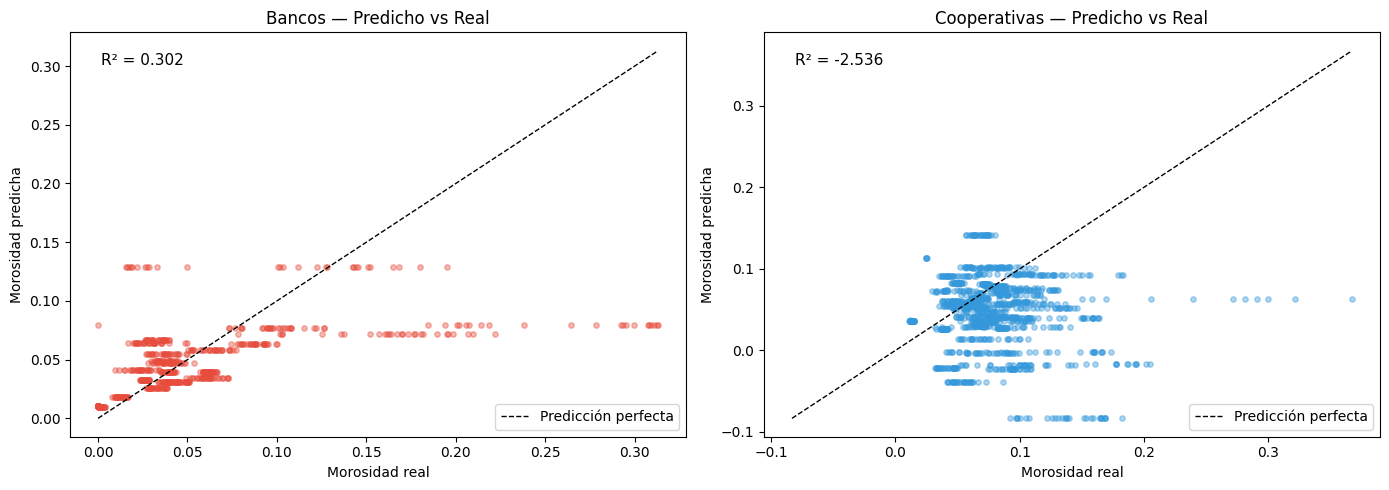

In [ ]:
# ─── Predicho vs Real ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, true, titulo, color in [
    (axes[0], pred_b_all, true_b_all, 'Bancos',       '#E74C3C'),
    (axes[1], pred_c_all, true_c_all, 'Cooperativas', '#3498DB'),
]:
    ax.scatter(true, pred, alpha=0.4, color=color, s=15)
    lim = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lim, lim, 'k--', linewidth=1, label='Predicción perfecta')
    ax.set_xlabel('Morosidad real')
    ax.set_ylabel('Morosidad predicha')
    ax.set_title(f'{titulo} — Predicho vs Real')
    r2 = r2_score(true, pred)
    ax.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=11)
    ax.legend()

plt.tight_layout()
plt.show()

# NOTAS:

# Mapear los indicadores con los del paper de 5 indicadores --------------------
# Matriz de correlacion de indicadores -----------------------------------------
# Incluir variables macro ------------------------------------------------------
# Arreglar gráficos ------------------------------------------------------------
# Tunear la red ----------------------------------------------------------------
# Cortar la serie de tiempo para tener coops -----------------------------------

In [ ]:
# ─── Guardar modelo en Drive ──────────────────────────────────────────────────
import shutil

SAVE_PATH = DRIVE_PATH + 'modelo_gnn_lstm_financiero.pt'
shutil.copy(CKPT_PATH, SAVE_PATH)
print(f'Modelo guardado en Drive: {SAVE_PATH}')

# Para cargar en el futuro:
# model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

Modelo guardado en Drive: /content/drive/MyDrive/GNN_SF/modelo_gnn_lstm_financiero.pt


## Guía de hiperparámetros para ajustar

Experimentar con:

| Hiperparámetro | Valor actual | Qué controla |
|---|---|---|
| `SEQ_LEN` | 6 | Meses de historia para la LSTM. Prueba 3, 6, 12 |
| `K_INTRA` | 5 | Vecinos k-NN dentro del mismo tipo. Más k = grafo más denso |
| `K_INTER` | 3 | Vecinos k-NN entre banco y cooperativa |
| `hidden_gnn` | 32 | Dimensión del espacio latente GNN |
| `n_gnn_layers` | 2 | Profundidad del GNN (radio de vecindad) |
| `n_heads` | 4 | Cabezas de atención en HGT |
| `hidden_lstm` | 32 | Dimensión oculta LSTM |
| `n_lstm_layers` | 2 | Capas LSTM |
| `dropout` | 0.2 | Regularización |
| `LR` | 1e-3 | Learning rate |
| `PATIENCE` | 15 | Early stopping |
